# データ取得

## タスクデータの取得

In [1]:

import os
import json

# ディレクトリパス
task_sets_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/InteractiveSmartHome/Assets/EXPERIMENT/ArrangeData"

# 対象ファイル
file_names = ["PreTaskArrangementA.json", "PreTaskArrangementB.json", 
              "PreTaskArrangementC.json", "PreTaskArrangementD.json"]

# すべてのタスクを格納するリスト
all_task_sets = []

# 各ファイルを読み込んで統合
for file_name in file_names:
    file_path = os.path.join(task_sets_path, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        all_task_sets.extend(data)  # 各ファイルがリスト形式であることを前提

# 確認（最初の1件だけ表示）
print(all_task_sets[0])




{'device_arrange_id': '2369c5c0-c4bb-4308-a9cd-05a64a69f91a', 'device_arrange_name': '手前三つ青奥三つ赤', 'device_arrange_type': [], 'devices': [{'deviceName': 'Ceiling Light 6', 'colorName': 'Blue', 'deviceId': '58126407-cde0-4d62-a13d-1a24bf8ea5f3'}, {'deviceName': 'Ceiling Light 2', 'colorName': 'Red', 'deviceId': '781e6091-cec9-4c26-9f3e-4d48d6d7570a'}, {'deviceName': 'Ceiling Light 4', 'colorName': 'Red', 'deviceId': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23'}, {'deviceName': 'Ceiling Light 3', 'colorName': 'Red', 'deviceId': '6f1c35e2-1ca1-4f43-93cf-755d9479025b'}, {'deviceName': 'Ceiling Light 8', 'colorName': 'Blue', 'deviceId': '74a6f0f8-be5d-479e-9e08-91d6bd599916'}, {'deviceName': 'Ceiling Light 7', 'colorName': 'Blue', 'deviceId': 'e9a21485-0eb4-40ad-a985-cef8bc98d190'}]}


## 処理結果の取得

In [2]:
import os
import json
from collections import defaultdict

# フォルダパス
result_dir = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/LLMServer/ExperimentData/RESULTS/SystemEvaluation"

# 除外する task_id のリスト（必要に応じて追加）
exclude_task_ids = {
    "b0e9f035-c92f-4dc6-bd0a-a10b2941f902"  # ← 外れ値
    # 他にも追加可能: "another-task-id", ...
}

# 結果を格納するネスト辞書
evaluation_results = defaultdict(dict)

# ファイル読み込みループ
for filename in os.listdir(result_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(result_dir, filename)
        # ファイル名から model名 と 評価方式を抽出
        parts = filename.replace("SystemEvaluation_", "").replace(".json", "").split("_")
        model = parts[0]
        eval_type = parts[1] if len(parts) > 1 else "unknown"

        # JSONロード＋task_id除外
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

            # データがリスト形式なら除外フィルターをかける
            if isinstance(data, list):
                filtered_data = [entry for entry in data if entry.get("task_id") not in exclude_task_ids]
                evaluation_results[model][eval_type] = filtered_data
            else:
                evaluation_results[model][eval_type] = data  # 念のため辞書型も対応

# 利用例
print(evaluation_results["gpt-4o"]["pointing"][0])  # 最初のタスクの出力を確認


{'user_prompt': 'この二つをオレンジにして ', 'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11', 'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424}, 'distance_from_user': 2.40738654, 'eye_centrality_score': 3.40282347e+38}, {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182', 'name': 'Ceiling Light 12', 'position': {'x': 1.83803356, 'y': 2.25890779, 'z': 1.54652917}, 'distance_from_user': 3.2973907, 'eye_centrality_score': 3.40282347e+38}], 'agent_output': {'devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}, {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}], 'response': '指定された二つのデバイスをオレンジに変更しました。', 'reasoning': 'ユーザーが指さしたデバイスを選択し、オレンジ色に設定しました。'}, 'metrics': {'model_name': 'gpt-4o-2024-08-06', 'tokens': {'prompt_tokens': 2381, 'completion_tokens': 217, 'total_tokens': 2598}, 'cost_usd': 0.008123, 'a

# メトリック処理

In [3]:
import pandas as pd 
# --- 実行時間抽出 ---
time_records = []

for model, modes in evaluation_results.items():
    for mode, results in modes.items():
        for entry in results:
            time_sec = entry.get("system_total_time_sec")
            task_id = entry.get("task_id")
            if time_sec is not None:
                time_records.append({
                    "model": model,
                    "mode": mode,
                    "task_id": task_id,
                    "time_sec": time_sec
                })

# --- DataFrame化 ---
df_times = pd.DataFrame(time_records)
df_times["mode"] = pd.Categorical(df_times["mode"], categories=["spatial", "pointing", "system"], ordered=True)

C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_times, x="mode", y="time_sec", hue="model", ci="sd")
C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:10: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  plt.tight_layout()
C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:10: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  plt.tight_layout()
C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:10: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from current font.
  plt.tight_layout()
C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:10: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from current font.
  plt.tight_layout()
C:\Users\Tenma\AppData\Local\Temp\ipykernel_14872\4281758236.py:10: U

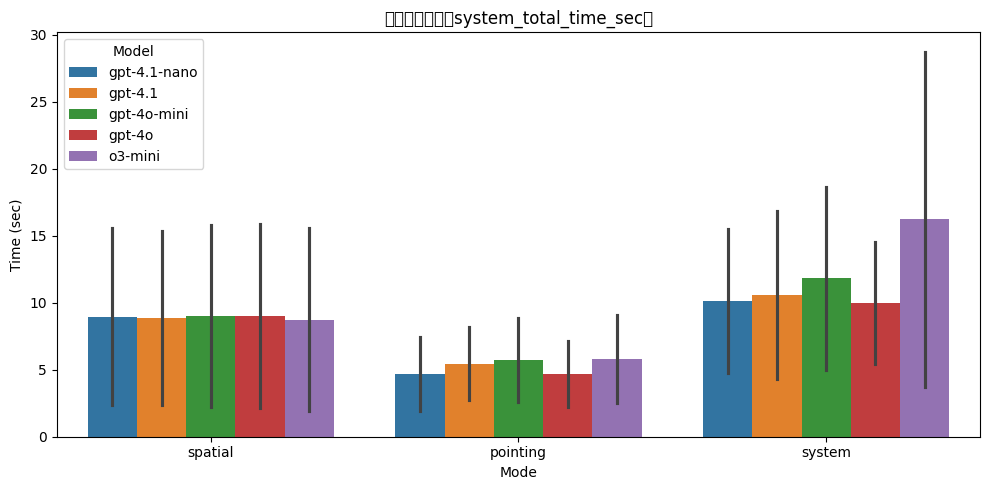

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=df_times, x="mode", y="time_sec", hue="model", ci="sd")
plt.title("平均実行時間（system_total_time_sec）")
plt.ylabel("Time (sec)")
plt.xlabel("Mode")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [5]:
# まず gpt-4o の spatial モードの時間分布を確認
df_times.query("model == 'gpt-4o' and mode == 'spatial'")["time_sec"].describe()


count    47.000000
mean      9.023715
std       6.848733
min       4.212652
25%       5.971435
50%       6.687830
75%       9.187712
max      43.360173
Name: time_sec, dtype: float64

In [6]:
# 対象抽出
df_sub = df_times.query("model == 'gpt-4o' and mode == 'spatial'")

# Q1, Q3, IQR計算
Q1 = df_sub["time_sec"].quantile(0.25)
Q3 = df_sub["time_sec"].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR  # 上側外れ値の閾値

# 外れ値に該当するタスク一覧
outliers = df_sub[df_sub["time_sec"] > threshold]

# 結果表示
print(f"上側外れ値の閾値: {threshold:.2f} 秒")
print(outliers[["task_id", "time_sec"]])


上側外れ値の閾値: 14.01 秒
                                  task_id   time_sec
472  7aeefa77-f398-4a26-b615-e50c4d05ba64  26.558485
475  386be10f-0686-4118-928d-b57f06593b2f  43.360173
476  2369c5c0-c4bb-4308-a9cd-05a64a69f91a  24.651706
500  8aeed698-e7ee-41ef-bfe7-56f37e2232ab  20.865153


## Metrics

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# agent_metrics から再構築
df_filter = df_agent_metrics[df_agent_metrics["agent_type"] == "filterAgent"].copy()
df_filter = df_filter.rename(columns={
    "agent_time": "agent_time_filter",
    "system_time": "system_time_filter",
    "prompt_tokens": "prompt_tokens_filter",
    "completion_tokens": "completion_tokens_filter",
    "total_tokens": "total_tokens_filter",
    "cost_usd": "cost_usd_filter",
    "model": "model_filter"
})

df_spatial = df_agent_metrics[df_agent_metrics["agent_type"] == "spatialAgent"].copy()
df_spatial = df_spatial.rename(columns={
    "agent_time": "agent_time_spatial",
    "system_time": "system_time_spatial",
    "prompt_tokens": "prompt_tokens_spatial",
    "completion_tokens": "completion_tokens_spatial",
    "total_tokens": "total_tokens_spatial",
    "cost_usd": "cost_usd_spatial",
    "model": "model_spatial"
})

df_total = pd.merge(df_filter, df_spatial, on="task_id")
df_total["agent_type"] = "totalAgent"
df_total["model"] = df_total["model_filter"]
df_total["agent_time"] = df_total["agent_time_filter"] + df_total["agent_time_spatial"]
df_total["system_time"] = df_total["system_time_filter"] + df_total["system_time_spatial"]
df_total["prompt_tokens"] = df_total["prompt_tokens_filter"] + df_total["prompt_tokens_spatial"]
df_total["completion_tokens"] = df_total["completion_tokens_filter"] + df_total["completion_tokens_spatial"]
df_total["total_tokens"] = df_total["total_tokens_filter"] + df_total["total_tokens_spatial"]
df_total["cost_usd"] = df_total["cost_usd_filter"] + df_total["cost_usd_spatial"]

df_total_summary = df_total[[
    "task_id", "model", "agent_type", "agent_time", "system_time",
    "prompt_tokens", "completion_tokens", "total_tokens", "cost_usd"
]]

df_filter_summary = df_agent_metrics[df_agent_metrics["agent_type"] == "filterAgent"].copy()
df_spatial_summary = df_agent_metrics[df_agent_metrics["agent_type"] == "spatialAgent"].copy()

df_agent_analysis = pd.concat([
    df_filter_summary,
    df_spatial_summary,
    df_total_summary
], ignore_index=True)

df_agent_analysis = df_agent_analysis[[
    "task_id", "model", "agent_type",
    "agent_time", "system_time",
    "prompt_tokens", "completion_tokens", "total_tokens", "cost_usd"
]]

# 集計：平均時間 + 合計コスト
avg_time = df_agent_analysis.groupby(["model", "agent_type"])[["agent_time", "system_time"]].mean().reset_index()
sum_cost = df_agent_analysis.groupby(["model", "agent_type"])[["cost_usd", "total_tokens"]].sum().reset_index()
df_summary = pd.merge(avg_time, sum_cost, on=["model", "agent_type"])

# 可視化：Agent別の平均処理時間
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary, x="agent_type", y="agent_time", hue="model")
plt.title("Agent別の平均処理時間")
plt.ylabel("平均Agent時間 (秒)")
plt.xlabel("Agent Type")
plt.tight_layout()
plt.show()


NameError: name 'df_agent_metrics' is not defined

# Metrics Visualize

## 値段

In [8]:



avg_cost = df_agent_metrics.groupby(["model", "agent_type"])["cost_usd"].mean().reset_index()

# ② 総トークン数 × 総コスト
total_cost = df_agent_metrics["cost_usd"].sum()
total_tokens = df_agent_metrics["total_tokens"].sum()

print(f"🌐 総コスト: ${total_cost:.4f}")
print(f"🔤 総トークン数: {total_tokens:,} tokens")
print(f"💰 1トークンあたり平均コスト: ${total_cost / total_tokens:.6f}")


NameError: name 'df_agent_metrics' is not defined

In [ ]:
# ① filterAgent と spatialAgent をそれぞれ抽出
df_filter = df_agent_metrics[df_agent_metrics["agent_type"] == "filterAgent"]
df_spatial = df_agent_metrics[df_agent_metrics["agent_type"] == "spatialAgent"]

# ② task_id で結合し、合計コストを作成
df_merged = pd.merge(df_filter, df_spatial, on=["task_id"], suffixes=("_filter", "_spatial"))

df_total = pd.DataFrame({
    "task_id": df_merged["task_id"],
    "model": df_merged["model_filter"],  # モデル名は共通のはず
    "agent_type": "totalAgent",
    "cost_usd": df_merged["cost_usd_filter"] + df_merged["cost_usd_spatial"]
})

# ③ トータルコストをモデル・agent_typeごとに集計（sum）
sum_cost_filter = df_filter.groupby(["model", "agent_type"])["cost_usd"].sum().reset_index()
sum_cost_spatial = df_spatial.groupby(["model", "agent_type"])["cost_usd"].sum().reset_index()
sum_cost_total = df_total.groupby(["model", "agent_type"])["cost_usd"].sum().reset_index()

# ④ 結合して1つの表に
sum_cost_all = pd.concat([sum_cost_filter, sum_cost_spatial, sum_cost_total], ignore_index=True)

# ⑤ プロット
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'Meiryo'  # 日本語対応（任意）

plt.figure(figsize=(10, 5))
sns.barplot(data=sum_cost_all, x="agent_type", y="cost_usd", hue="model")
plt.title("Agentごとの総コスト（USD）")
plt.ylabel("Total Cost (USD)")
plt.xlabel("Agent Type")
plt.tight_layout()
plt.show()


# 性能評価

In [ ]:
a = evaluation_results["gpt-4o"]["system"][0]
for i in a:
    print(i)

In [ ]:
a = evaluation_results["gpt-4o"]["pointing"][0]
a["agent_output"]

In [ ]:
a = evaluation_results["gpt-4o"]["spatial"][0]
for i in a:
    print(i)

In [ ]:
all_task_sets

In [ ]:
# 1. device_arrange_id → task_info のマップを作る
task_id_to_info = {}

for task in all_task_sets:
    task_id_to_info[task["device_arrange_id"]] = {
        "name": task["device_arrange_name"],
        "devices": task["devices"]
    }

# 2. タスクの例を確認
example = evaluation_results["gpt-4o"]["system"][0]
task_id = example["task_id"]

# 対応する名前やデバイス情報を取得
if task_id in task_id_to_info:
    print("✅ タスクID:", task_id)
    print("📘 配置名:", task_id_to_info[task_id]["name"])
    print("💡 デバイス:", task_id_to_info[task_id]["devices"])
else:
    print("❌ 対応する task_id が見つかりません")


In [ ]:
# 例: 評価結果から task_id を取得
example = evaluation_results["gpt-4o"]["system"][0]
task_id = example["task_id"]

# 正解デバイスID（deviceId を使う）
gt_ids = {d["deviceId"] for d in task_id_to_info[task_id]["devices"]}

# 予測デバイスID（id を使う）
pred_ids = {d["id"] for d in example["selected_devices"]}

# 一致判定
is_correct = pred_ids == gt_ids
print("✅ 正解" if is_correct else "❌ 不正解")


In [ ]:
correct = 0
total = 0

for item in evaluation_results["gpt-4o"]["system"]:
    task_id = item["task_id"]
    if task_id not in task_id_to_info:
        continue

    gt_ids = {d["deviceId"] for d in task_id_to_info[task_id]["devices"]}
    pred_ids = {d["id"] for d in item["selected_devices"]}

    if pred_ids == gt_ids:
        correct += 1
    total += 1

accuracy = correct / total if total > 0 else 0
print(f"🎯 Accuracy: {accuracy:.2%} ({correct}/{total})")


## まとめて

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
matplotlib.rcParams['font.family'] = 'Meiryo'  # 日本語対応（任意）

# ----------------------------
# ① メトリクスを計算する関数
# ----------------------------
def calculate_metrics(gt_ids, pred_ids):
    is_exact = (gt_ids == pred_ids)
    inter = gt_ids & pred_ids
    precision = len(inter) / len(pred_ids) if pred_ids else 0
    recall = len(inter) / len(gt_ids) if gt_ids else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0
    return is_exact, precision, recall, f1

# ----------------------------
# ② 評価結果を DataFrame に変換する関数
# ----------------------------
def build_evaluation_dataframe(evaluation_results, task_id_to_info):
    rows = []
    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                task_id = record["task_id"]
                attempt = record.get("attempt_id", None)

                gt_ids = {d.get("deviceId", d.get("id")) for d in task_id_to_info[task_id]["devices"]}
                if eval_type == "pointing":
                    sel = record["agent_output"]["devices"]
                    metrics = record["metrics"]
                else:
                    sel = record["selected_devices"]
                    agent_key = "filterAgent" if eval_type == "system" else "spatialAgent"
                    metrics = record[agent_key]["metrics"]

                pred_ids = {d["id"] for d in sel}
                is_exact, precision, recall, f1 = calculate_metrics(gt_ids, pred_ids)

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "task_id": task_id,
                    "attempt_id": attempt,
                    "n_gt": len(gt_ids),
                    "n_pred": len(pred_ids),
                    "exact_match": float(is_exact),
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                    "cost_usd": metrics.get("cost_usd"),
                    "agent_time_sec": metrics.get("agent_time_elapsed"),
                    "system_time_sec": metrics.get("system_time_elapsed"),
                })
    return pd.DataFrame(rows)

# ----------------------------
# ③ 指定の指標を可視化する関数
# ----------------------------
def visualize_summary_metrics(df_summary, metric, title, ylabel):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_summary, x="eval_type", y=metric, hue="model")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Evaluation Type")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# ----------------------------
# メイン処理
# ----------------------------
df_eval = build_evaluation_dataframe(evaluation_results, task_id_to_info)
df_summary = df_eval.groupby(["model", "eval_type"]).mean(numeric_only=True).reset_index()

# 指標ごとに可視化
visualize_summary_metrics(df_summary, "exact_match", "正解率 (Exact Match)", "Accuracy")
visualize_summary_metrics(df_summary, "f1", "F1スコア", "F1-score")
visualize_summary_metrics(df_summary, "cost_usd", "合計コスト (USD)", "Total Cost (USD)")
visualize_summary_metrics(df_summary, "agent_time_sec", "平均 Agent 実行時間 (秒)", "Agent Time (sec)")


# a 

In [ ]:
single_task = [task for task in all_task_sets if len(task["devices"]) == 1]
multiple_task =  [task for task in all_task_sets if len(task["devices"]) > 1]

In [ ]:
len(multiple_task)